In [1]:
import os
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE  # Thêm SMOTE để xử lý dữ liệu không cân bằng
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from pandas import DataFrame, concat
import warnings
warnings.filterwarnings('ignore')

# Giả định: Hàm create_transformer_model đã được định nghĩa
from transformer_model import create_transformer_model, Attention

In [2]:
# Hàm chuyển đổi chuỗi dữ liệu thành dạng học supervised learning
def series_to_supervised(data, n_in=1, n_out=1, dropnan=True):
    n_vars = 1 if type(data) is list else data.shape[1]
    df = DataFrame(data)
    cols, names = list(), list()
    # input sequence (t-n, ... t-1)
    for i in range(n_in, 0, -1):
        cols.append(df.shift(i))
        names += [('var%d(t-%d)' % (j+1, i)) for j in range(n_vars)]
    # forecast sequence (t, t+1, ... t+n)
    for i in range(0, n_out):
        cols.append(df.shift(-i))
        if i == 0:
            names += [('var%d(t)' % (j+1)) for j in range(n_vars)]
        else:
            names += [('var%d(t+%d)' % (j+1, i)) for j in range(n_vars)]
    # put it all together
    agg = concat(cols, axis=1)
    agg.columns = names
    # drop rows with NaN values
    if dropnan:
        agg.dropna(inplace=True)
    return agg

In [3]:
# Đọc dữ liệu
df_pre = pd.read_csv(r'C:\Users\leduc\SGU\Nghiencuukhoahoc\DATA-20241004T011516Z-001\DATA\Merged_PM2.5_AQI_18_23.csv', sep=",", dtype=str)
df_pre = df_pre[['AQI Category', 'wd', 'ws', 'Rainfall', 'low_leaf', 'temp', 'uvb']]

In [4]:
# Mã hóa nhãn
label_encoder = LabelEncoder()
df_pre['AQI Category'] = label_encoder.fit_transform(df_pre['AQI Category'])

# Chuyển đổi sang float32
feature_columns = ['wd', 'ws', 'Rainfall', 'low_leaf', 'temp', 'uvb']
df_pre[feature_columns] = df_pre[feature_columns].astype('float32')

In [5]:
# Chuẩn hóa đặc trưng
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_features = scaler.fit_transform(df_pre[feature_columns])
scaled = np.concatenate([df_pre[['AQI Category']].values, scaled_features], axis=1)

In [36]:
# Chuyển đổi thành dạng supervised learning
n_hours = 24
n_features = len(feature_columns) + 1
reframed = series_to_supervised(scaled, n_in=n_hours, n_out=1)

In [37]:
# Chia dữ liệu thành input (X) và output (y)
n_obs = n_hours * n_features
X = reframed.iloc[:, :n_obs].values
y = reframed.iloc[:, n_obs].values  # Nhãn tại thời điểm t

In [38]:
# Debug: Kiểm tra nhãn
print("Unique labels in y_train before split:", np.unique(y))

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Debug: Kiểm tra sau khi chia
print("Unique labels in y_train after split:", np.unique(y_train))
print("Unique labels in y_test:", np.unique(y_test))

Unique labels in y_train before split: [0. 1. 2. 3. 4.]
Unique labels in y_train after split: [0. 1. 2. 3. 4.]
Unique labels in y_test: [0. 1. 2. 3. 4.]


In [39]:
# Áp dụng SMOTE với k_neighbors=2 để tránh lỗi khi số mẫu nhỏ
smote = SMOTE(random_state=42, k_neighbors=2)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# Debug: Kiểm tra sau SMOTE
print("Unique labels in y_train_resampled:", np.unique(y_train_resampled))

# Reshape dữ liệu
X_train_resampled = X_train_resampled.reshape((X_train_resampled.shape[0], n_hours, n_features))
X_test = X_test.reshape((X_test.shape[0], n_hours, n_features))

Unique labels in y_train_resampled: [0. 1. 2. 3. 4.]


In [40]:
# Số lớp
num_classes = len(label_encoder.classes_)
print("Number of classes:", num_classes)

# Giữ y_train_resampled là vector integer (SMOTE trả về integers)
y_train_resampled_int = y_train_resampled.astype(int)

# Chuyển y_test về integer (nếu hiện đang one-hot)
y_test_int = np.argmax(y_test, axis=1) if y_test.ndim>1 else y_test.astype(int)


Number of classes: 5


In [41]:
# Tính class weights từ dữ liệu đã SMOTE (phù hợp khi dùng class_weight)
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
y_train_resampled_int = y_train_resampled.astype(int)
class_labels = np.unique(y_train_resampled_int)
cw = compute_class_weight(class_weight='balanced', classes=class_labels, y=y_train_resampled_int)
class_weights = {int(label): float(weight) for label, weight in zip(class_labels, cw)}
print("Class weights (from resampled):", class_weights)

Class weights (from resampled): {0: 1.0, 1: 1.0, 2: 1.0, 3: 1.0, 4: 1.0}


In [42]:
# Cố định seed để kết quả lặp lại tốt hơn
import numpy as _np
import tensorflow as _tf
_np.random.seed(42)
_tf.random.set_seed(42)

In [43]:
# ...existing code...
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import Layer, Dense, LayerNormalization, Dropout, Input, GlobalAveragePooling1D
from tensorflow.keras.models import Model

def positional_encoding(seq_len, d_model):
    """Sinusoidal positional encoding (batch dim added)."""
    pos = np.arange(seq_len)[:, np.newaxis]
    i = np.arange(d_model)[np.newaxis, :]
    angle_rates = 1 / np.power(10000.0, (2 * (i // 2)) / np.float32(d_model))
    angle_rads = pos * angle_rates
    pos_encoding = np.zeros((seq_len, d_model), dtype=np.float32)
    pos_encoding[:, 0::2] = np.sin(angle_rads[:, 0::2])
    pos_encoding[:, 1::2] = np.cos(angle_rads[:, 1::2])
    return tf.cast(pos_encoding[np.newaxis, ...], tf.float32)

class Attention(Layer):
    """
    Simple attention layer that computes a weighted sum across time steps.
    Returns context vector with shape (batch, channels). Also exposes
    last attention weights via `last_weights`.
    """
    def __init__(self, units=32, **kwargs):
        super().__init__(**kwargs)
        self.units = units
        self.w1 = Dense(units, activation='tanh')
        self.w2 = Dense(1, activation=None)

    def call(self, inputs, mask=None):
        # inputs: (batch, time, features)
        score = self.w2(self.w1(inputs))            # (batch, time, 1)
        if mask is not None:
            mask = tf.cast(mask, score.dtype)
            score = score + (1.0 - mask[..., tf.newaxis]) * -1e9
        weights = tf.nn.softmax(score, axis=1)      # (batch, time, 1)
        context = tf.reduce_sum(weights * inputs, axis=1)  # (batch, features)
        # save for inspection
        self.last_weights = tf.squeeze(weights, axis=-1)
        return context

    def get_config(self):
        cfg = super().get_config()
        cfg.update({"units": self.units})
        return cfg

def create_transformer_model(input_shape, d_model=64, num_heads=4, dff=128,
                             num_layers=2, dropout_rate=0.2, use_positional=True):
    """
    Encoder-only Transformer model.
    input_shape: (seq_len, n_features)
    Returns a tf.keras.Model that outputs a pooled feature vector (ready for Dense classifier).
    """
    seq_len, _ = input_shape
    inputs = Input(shape=input_shape, name="inputs")

    # project input features to d_model
    x = Dense(d_model, name="input_projection")(inputs)

    # positional encoding
    if use_positional:
        pos_enc = positional_encoding(seq_len, d_model)
        x = x + pos_enc[:, :seq_len, :]

    for i in range(num_layers):
        # Multi-head self-attention
        attn = tf.keras.layers.MultiHeadAttention(
            num_heads=num_heads,
            key_dim=max(1, d_model // num_heads),
            name=f"mha_{i}"
        )(x, x, attention_mask=None)
        attn = Dropout(dropout_rate, name=f"mha_dropout_{i}")(attn)
        x = LayerNormalization(epsilon=1e-6, name=f"mha_ln_{i}")(x + attn)

        # Feed-forward
        ffn = Dense(dff, activation='relu', name=f"ffn1_{i}")(x)
        ffn = Dense(d_model, name=f"ffn2_{i}")(ffn)
        ffn = Dropout(dropout_rate, name=f"ffn_dropout_{i}")(ffn)
        x = LayerNormalization(epsilon=1e-6, name=f"ffn_ln_{i}")(x + ffn)

    # global pooling -> feature vector
    pooled = GlobalAveragePooling1D(name="global_avg_pool")(x)

    return Model(inputs=inputs, outputs=pooled, name="transformer_encoder")
# ...existing code...

In [44]:
# Tạo mô hình (giữ create_cnn_transformer_model như trước)
base_model = create_transformer_model(input_shape=(n_hours, n_features))
model = tf.keras.Sequential([base_model, Dense(num_classes, activation='softmax')])

In [45]:
# Tính trọng số lớp
class_counts = np.bincount(y_train.astype(int))
print("Class counts:", class_counts)
class_weights = {
    i: float((1 / class_counts[i]) * (len(y_train) / num_classes)) if class_counts[i] > 0 else 0.0
    for i in range(num_classes)
}
print("Class weights:", class_weights)

Class counts: [ 4614 20577  1263  3627     3]
Class weights: {0: 1.3040312093628088, 1: 0.29240414054526903, 2: 4.7638954869358665, 3: 1.6588916459884202, 4: 2005.6}


In [46]:
# Biên dịch: dùng sparse loss và lr nhỏ hơn + gradient clipping
y_test_int = np.argmax(y_test, axis=1) if y_test.ndim>1 else y_test.astype(int)
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4, clipnorm=1.0)
model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)

In [47]:
# Huấn luyện
history = model.fit(
    X_train_resampled, y_train_resampled,
    validation_data=(X_test, y_test),
    epochs=100,
    batch_size=64,
    class_weight=class_weights,
    callbacks=[early_stopping, lr_scheduler],
    verbose=1
)

Epoch 1/100
1608/1608 ━━━━━━━━━━━━━━━━━━━━ 39s 20ms/step - accuracy: 0.4262 - loss: 28.6021 - val_accuracy: 0.2663 - val_loss: 1.6204 - learning_rate: 1.0000e-04
Epoch 2/100
1608/1608 ━━━━━━━━━━━━━━━━━━━━ 32s 20ms/step - accuracy: 0.6841 - loss: 0.8271 - val_accuracy: 0.4642 - val_loss: 1.2561 - learning_rate: 1.0000e-04
Epoch 3/100
1608/1608 ━━━━━━━━━━━━━━━━━━━━ 32s 20ms/step - accuracy: 0.7789 - loss: 0.5987 - val_accuracy: 0.4903 - val_loss: 1.1647 - learning_rate: 1.0000e-04
Epoch 4/100
1608/1608 ━━━━━━━━━━━━━━━━━━━━ 32s 20ms/step - accuracy: 0.7939 - loss: 0.5493 - val_accuracy: 0.5047 - val_loss: 1.1503 - learning_rate: 1.0000e-04
Epoch 5/100
1608/1608 ━━━━━━━━━━━━━━━━━━━━ 32s 20ms/step - accuracy: 0.8013 - loss: 0.5341 - val_accuracy: 0.4963 - val_loss: 1.1503 - learning_rate: 1.0000e-04
Epoch 6/100
1608/1608 ━━━━━━━━━━━━━━━━━━━━ 32s 20ms/step - accuracy: 0.8065 - loss: 0.5231 - val_accuracy: 0.5303 - val_loss: 1.0812 - learning_rate: 1.0000e-04
Epoch 7/100
1608/1608 ━━━━━━━━━━━

236/236 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
Shapes: X_test: (7522, 24, 7) y_true: (7522,) y_pred: (7522,)
Unique y_true counts: [1153 5145  316  907    1]
Unique y_pred counts: [2730 2484  294 1994   20]
Classification Report:
                                precision    recall  f1-score   support

                          Good       0.40      0.95      0.56      1153
                      Moderate       0.96      0.46      0.62      5145
                     Unhealthy       0.76      0.70      0.73       316
Unhealthy for Sensitive Groups       0.38      0.85      0.53       907
                Very Unhealthy       0.00      0.00      0.00         1

                      accuracy                           0.59      7522
                     macro avg       0.50      0.59      0.49      7522
                  weighted avg       0.79      0.59      0.61      7522



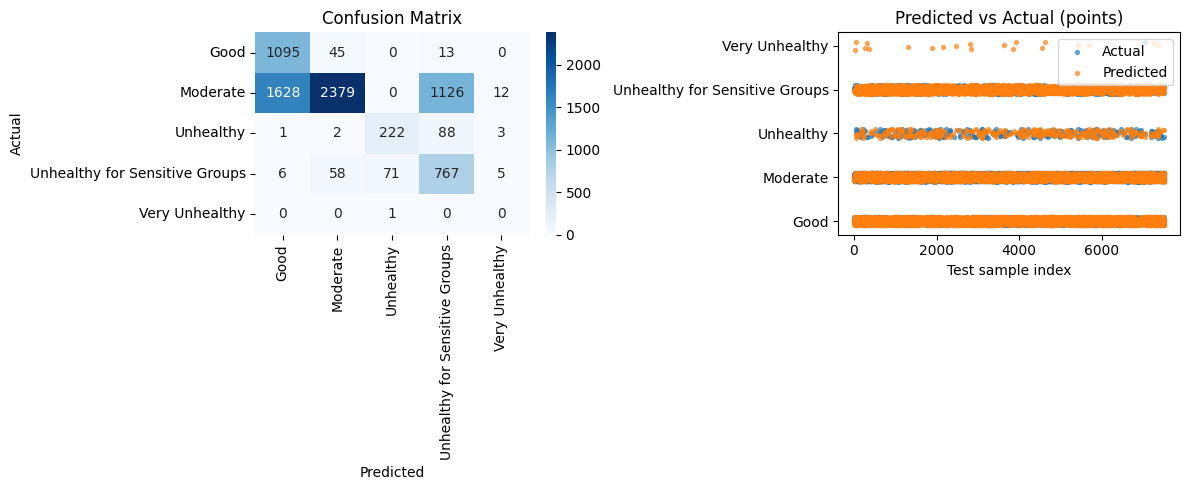

In [48]:
# ...existing code...
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Lấy y_true nhất quán (ưu tiên y_test_int nếu có)
if 'y_test_int' in globals():
    y_true = y_test_int
elif 'y_test_classes' in globals():
    # convert one-hot -> int nếu cần
    y_true = np.argmax(y_test_classes, axis=1) if getattr(y_test_classes, 'ndim', 1) > 1 else y_test_classes
else:
    # fallback: try derive from y_test
    y_true = np.argmax(y_test, axis=1) if getattr(y_test, 'ndim', 1) > 1 else y_test

# y_pred_classes từ model.predict
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

# In kiểm tra shape và một vài giá trị để debug
print("Shapes: X_test:", getattr(X_test, 'shape', None), "y_true:", y_true.shape, "y_pred:", y_pred_classes.shape)
print("Unique y_true counts:", np.bincount(y_true.astype(int)))
print("Unique y_pred counts:", np.bincount(y_pred_classes.astype(int)))

# Nếu mismatch về số mẫu, cắt xuống min để tránh lỗi
if y_pred_classes.shape[0] != y_true.shape[0]:
    n = min(y_pred_classes.shape[0], y_true.shape[0])
    print(f"Warning: length mismatch (pred={y_pred_classes.shape[0]}, true={y_true.shape[0]}). Trimming to {n}.")
    y_pred_classes = y_pred_classes[:n].astype(int)
    y_true = y_true[:n].astype(int)

# Classification report (sử dụng same y_true)
print("Classification Report:")
print(classification_report(y_true, y_pred_classes, target_names=label_encoder.classes_))

# Confusion matrix + scatter
cm = confusion_matrix(y_true, y_pred_classes, labels=np.arange(len(label_encoder.classes_)))
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel('Predicted'); plt.ylabel('Actual'); plt.title('Confusion Matrix')

plt.subplot(1,2,2)
idx = np.arange(len(y_true))
jitter = (np.random.RandomState(0).rand(len(idx)) - 0.5) * 0.2
plt.scatter(idx, y_true + jitter, s=8, c='C0', label='Actual', alpha=0.6)
plt.scatter(idx, y_pred_classes - jitter, s=8, c='C1', label='Predicted', alpha=0.6)
plt.yticks(np.arange(len(label_encoder.classes_)), label_encoder.classes_)
plt.xlabel('Test sample index'); plt.title('Predicted vs Actual (points)')
plt.legend(loc='upper right')
plt.tight_layout()
plt.savefig(f'AQI_pred_vs_actual_timestep_{n_hours}_checked.png', dpi=200)
plt.show()

In [49]:
# Lưu kết quả với cột dự đoán và cột thực tế
# y_pred_classes đã có sẵn
y_pred_labels = label_encoder.inverse_transform(y_pred_classes)

# Tìm biến nhãn test hợp lệ trong notebook (sử dụng thứ tự ưu tiên)
if 'y_test_classes' in globals():
    y_test_arr = y_test_classes
elif 'y_test_int' in globals():
    y_test_arr = y_test_int
elif 'y_true' in globals():
    y_test_arr = y_true
elif 'y_test' in globals():
    # nếu y_test là one-hot hoặc vector
    y_test_arr = np.argmax(y_test, axis=1) if getattr(y_test, 'ndim', 1) > 1 else y_test.astype(int)
else:
    raise NameError("Không tìm thấy biến nhãn test (y_test_classes, y_test_int, y_true hoặc y_test).")

# đảm bảo integer và đảo mã nhãn
y_test_arr = np.asarray(y_test_arr).astype(int)
y_test_labels = label_encoder.inverse_transform(y_test_arr)

output = pd.DataFrame({
    'Predicted_AQI_Category': y_pred_labels,
    'Actual_AQI_Category': y_test_labels
})
output.to_csv(f'Transformer_AQI_Classification_timestep_{n_hours}_optimized.csv', index=False)


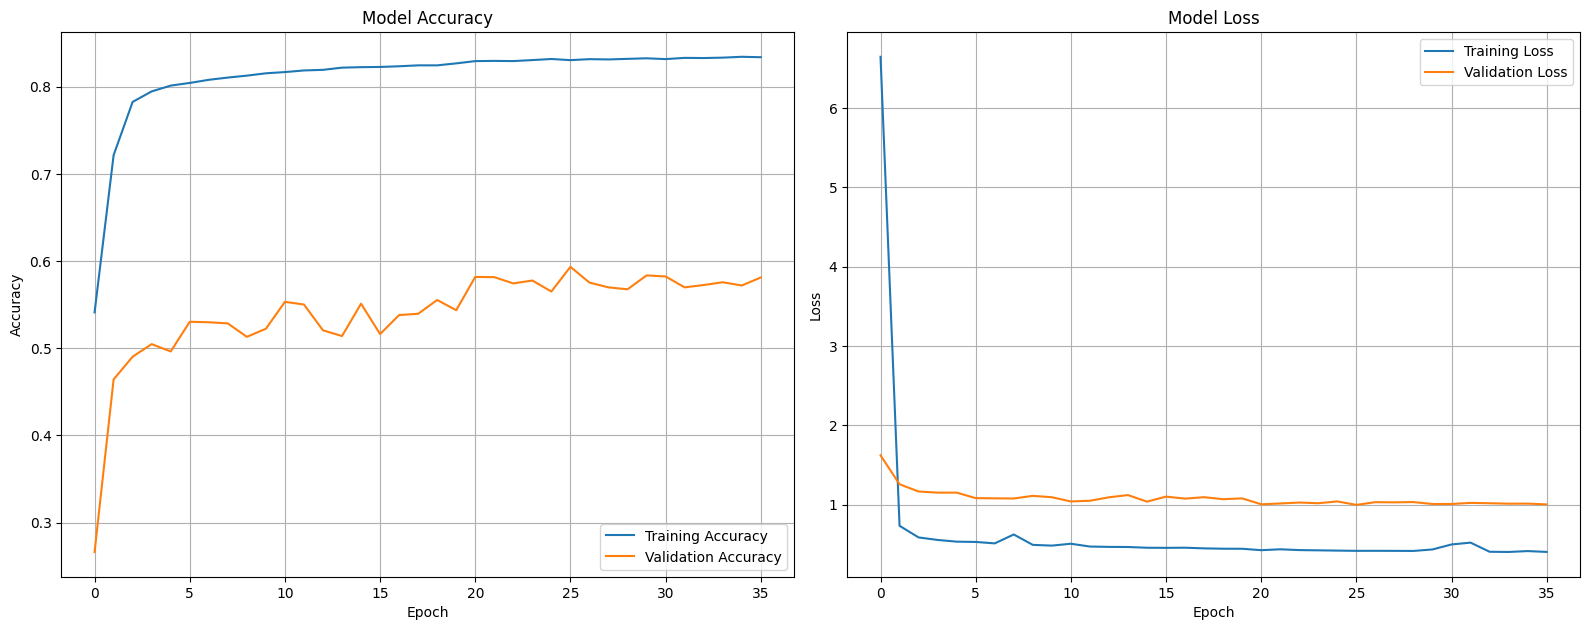

In [50]:
# Vẽ biểu đồ
import matplotlib.pyplot as plt
plt.figure(figsize=(16, 12))
plt.subplot(2, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()
plt.grid(True)
plt.subplot(2, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()